In [1]:
import numpy as np
from scipy.optimize import linprog
from time import perf_counter
import matplotlib.pyplot as plt

# 1. Modelado de baterías

Los sistemas de almacenamiento de energía son de gran utilidad en situaciones en las
que hay incertidumbre acerca de la producción o la demanda de energía. Por este motivo,
en la actualidad, estos sistemas tienen muchas aplicaciones en el aprovechamiento de las
energías renovables, en alza, o de los modelos que involucren sistemas de almacenamiento
mediante baterías.

Supongamos que tenemos una batería cuya capacidad queremos modelar a lo largo del tiempo.
Denotaremos $x_t$ como la *potencia* de carga en el instante $t$, de forma que $x_t > 0$ si la batería está cargando y $x_t < 0$ si está descargando.
Además, llamaremos $E_t$ a la *energía* almacenada en el instantef $t$.
Suponiendo que no hay pérdidas de ningún tipo, se verifica que
$$E_t = \sum_{\tau = 1}^t x_\tau.$$
Como trabajamos con tiempo discreto, se puede considerar el vector $x = (x_1,\cdots, x_T)$ que representala una selección de potencias en cada instante de tiempo.
Estos objetos se llamarán *perfiles* de carga.
El poliedro factible de estos perfiles es
$$\mathcal{F}_T = \left\{x \in \mathbb{R}^T :
    x_{min} \leq x_t \leq x_{max}, \quad
    E_{min} \leq \sum_{\tau=1}^{t} \leq E_{max} \quad
    \forall\ t \right\},$$
donde $x_{min} \leq 0 \leq x_{max}$, $E_{min} \leq 0 \leq E_{max}$.

**Teorema**
    $\mathcal{F}_T$ es un polimatroide generalizado. Es decir, $\mathcal{F}_T = Q(p,b)$ donde $(p,b)$ es un par paramodular.
Como $\mathcal{F}_T$ tiene esta estructura, se puede aplicar el algoritmo de Edmonds para resolver problemas del tipo
$$ \max \{c'x : x \in \mathcal{F}_T\}.$$
En la siguiente celda, la función `lp_bateria` resuelve el problema de Programación Lineal mediante el algoritmo de Edmonds.

In [2]:

def lp_bateria(x_min, x_max, E_0, E_max, c):
    """
    c: np.array(T)
    Suponemos que c es de valores positivos
    """
    T = len(c)
    t0 = perf_counter()
    c1 = np.argsort(-c) # Lista de costes ordenada de mayor a menor.
    c2 = np.array(range(T))
    c2[c1] = c2 # c2[i] = j Significa que i \in S_j , y es el menor S_* con esta propiedad
    b_S = np.zeros(shape=T+1) # b_S[i] = b(S_i)
    E = E_0*np.ones(T) # Cargas acumuladas.
    # Cada elemento de E representará una simulación de la batería al resolver el problema
    # max(x(b(S_u)) : x \in F_t) de forma avariciosa
    
    for t in range(T):
        U = c2[t] # Minimo S_U que contiene a t
        E[:U] = np.maximum(0, E[:U]+x_min)
        carga = np.minimum(x_max, E_max-E[U:])
        E[U:] += carga 
        b_S[U+1:] += carga 
    # A continuación, calculamos los x a partir de los b_S.
    x = np.zeros(T)
    valor_optimo = 0
    x[c1] = b_S[1:] - b_S[:-1]
    valor_optimo = np.sum(c*x)
    t1 = perf_counter()
    return valor_optimo, x, t1-t0



La siguiente celula implementa una solución el mismo problema, pero lo resuelve utilizando el solver estándar *highs*.

In [3]:
def resolver_con_simplex(x_min, x_max, E_0, E_max, c):
    T = len(c)
    
    # 1. Función objetivo (SciPy minimiza, por eso usamos -c)
    obj = -c
    
    # 2. Construcción de la matriz de restricciones A_ub * x <= b_ub
    # Tenemos 2*T restricciones de energía (T superiores y T inferiores)
    A_ub = np.vstack([np.tril(np.ones(shape=(T,T))), -np.tril(np.ones(shape=(T,T)))])
    b_ub = np.zeros(2 * T)
    b_ub[:T] = E_max
    b_ub[T:] = E_0
    


    # 3. Límites de las variables (x_min <= x_t <= x_max)
    bordes = [(x_min, x_max) for _ in range(T)]

    # 4. Llamada al solver (usando el método 'highs')
    t0 = perf_counter()
    
    res = linprog(obj, A_ub=A_ub, b_ub=b_ub, bounds=bordes, method='highs')
    
    t1 = perf_counter()
    
    return res.fun * -1, res.x, t1 - t0

# 2. Comparación algoritmo polimatroide vs solver.

Las siguientes células resuelven el problema lineal sobre la batería con distintos horizontes temporales. Se ha hecho una gráfica con el tiempo de ejecución por horizonte temporal, con el fin de ver la evolución.

In [4]:
x_min, x_max, E_0, E_max = -2.2, 1.4, 0, 2.3
np.random.seed(0)
c = np.random.uniform(size=4000)
Ts = np.array([500, 1000, 1500, 2000, 2500, 3000, 3500, 4000])
tiempo_poly = np.zeros(len(Ts))
tiempo_solver = np.zeros(len(Ts))
for i, T in enumerate(Ts):
    _, x_simplex, tiempo_solver[i] = resolver_con_simplex(x_min, x_max, E_0, E_max, c[:T])
    _, x_bateria, tiempo_poly[i] = lp_bateria(x_min, x_max, E_0, E_max, c[:T])
    print("T =", T, ":", np.linalg.norm(x_simplex-x_bateria, np.inf) < 1e-5) # Testea si las soluciones coinciden.



T = 500 : True
T = 1000 : True
T = 1500 : True
T = 2000 : True
T = 2500 : True
T = 3000 : True
T = 3500 : True
T = 4000 : True


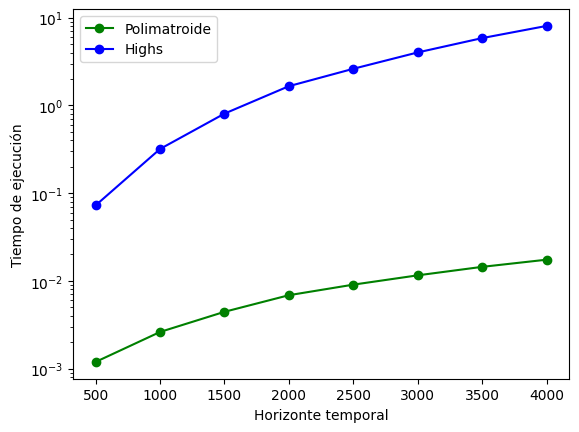

In [5]:
plt.figure()
plt.plot(Ts, tiempo_poly, 'go-')
plt.plot(Ts, tiempo_solver, 'bo-')
plt.yscale('log')
plt.xlabel('Horizonte temporal')
plt.ylabel('Tiempo de ejecución')
plt.legend(['Polimatroide', 'Highs'])
#plt.savefig("comparativa-polimatroide-highs.pdf")
plt.show()

Nótese que la escala es logarítmica. Aquí podemos ver que el algoritmo dado por la estructura de polimatroide generalizado es dos órdenes de magnitud más rápido que el solver *highs*.